In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

# Load RFM data
rfm = pd.read_csv("../data/features/rfm_features.csv")

print("RFM data loaded!")
print("Shape:", rfm.shape)
print("Columns:", list(rfm.columns))
print()
print(rfm.head())

RFM data loaded!
Shape: (5878, 5)
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Churned']

   CustomerID  Recency  Frequency  Monetary  Churned
0       12346      326         12  77556.46        1
1       12347        2          8   4921.53        0
2       12348       75          5   2019.40        0
3       12349       19          4   4428.69        0
4       12350      310          1    334.40        1


In [2]:
# Apply log transformation to handle skewness
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].copy()
rfm_log['Recency']   = np.log1p(rfm['Recency'])
rfm_log['Frequency'] = np.log1p(rfm['Frequency'])
rfm_log['Monetary']  = np.log1p(rfm['Monetary'])

print("Before log transformation:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

print("\nAfter log transformation:")
print(rfm_log.describe().round(2))

# Scale the data (mean=0, std=1)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

print("\nScaling done!")
print("Shape of scaled data:", rfm_scaled.shape)

Before log transformation:
       Recency  Frequency   Monetary
count  5878.00    5878.00    5878.00
mean    201.33       6.29    2955.90
std     209.34      13.01   14440.85
min       1.00       1.00       2.95
25%      26.00       1.00     342.28
50%      96.00       3.00     867.74
75%     380.00       7.00    2248.30
max     739.00     398.00  580987.04

After log transformation:
       Recency  Frequency  Monetary
count  5878.00    5878.00   5878.00
mean      4.45       1.55      6.82
std       1.56       0.81      1.39
min       0.69       0.69      1.37
25%       3.30       0.69      5.84
50%       4.57       1.39      6.77
75%       5.94       2.08      7.72
max       6.61       5.99     13.27

Scaling done!
Shape of scaled data: (5878, 3)


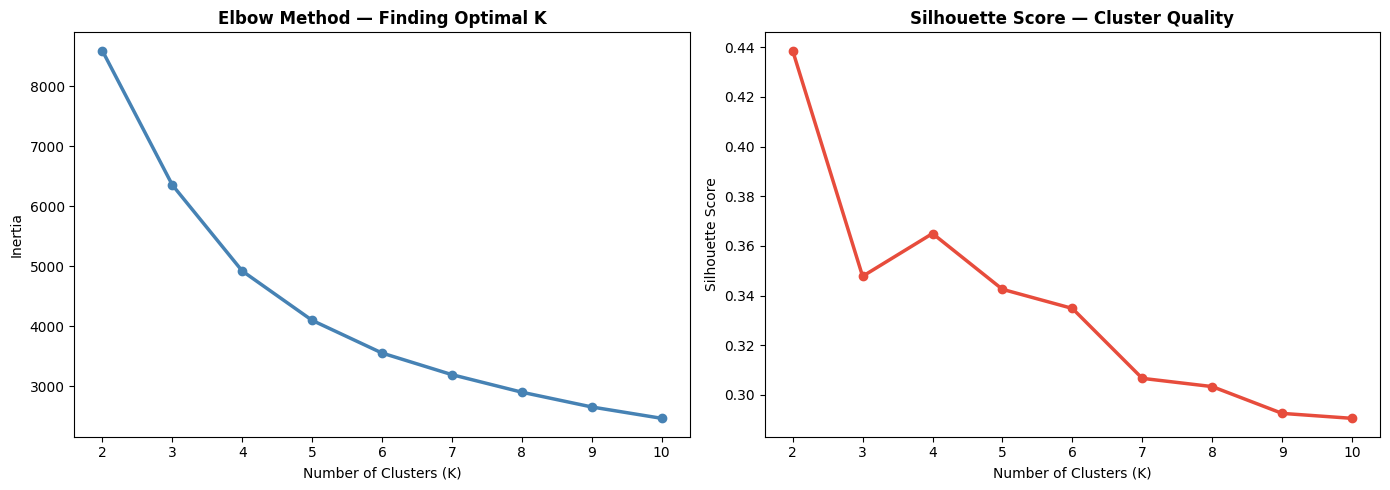

Silhouette Scores:
  K=2  →  0.4386
  K=3  →  0.3477
  K=4  →  0.3650
  K=5  →  0.3425
  K=6  →  0.3348
  K=7  →  0.3066
  K=8  →  0.3033
  K=9  →  0.2925
  K=10  →  0.2905


In [3]:
# Find best number of clusters using Elbow Method
inertia = []
silhouette = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(rfm_scaled, kmeans.labels_))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(K, inertia, marker='o', color='steelblue', linewidth=2.5)
axes[0].set_title('Elbow Method — Finding Optimal K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

# Silhouette score
axes[1].plot(K, silhouette, marker='o', color='#e74c3c', linewidth=2.5)
axes[1].set_title('Silhouette Score — Cluster Quality', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('../reports/plots/segmentation_elbow.png', dpi=150)
plt.show()

print("Silhouette Scores:")
for k, s in zip(K, silhouette):
    print(f"  K={k}  →  {s:.4f}")

In [4]:
# Train KMeans with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("KMeans trained successfully!")
print()
print("Customers per cluster:")
print(rfm['Cluster'].value_counts().sort_index())

KMeans trained successfully!

Customers per cluster:
Cluster
0    1973
1    1250
2    1196
3    1459
Name: count, dtype: int64


In [5]:
# Analyse RFM values per cluster {Analyze each cluster}
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(2)
print("Cluster RFM Summary:")
print(cluster_summary)

Cluster RFM Summary:
         Recency  Frequency  Monetary
Cluster                              
0         394.95       1.38    317.08
1          28.30       3.05    857.49
2          27.71      19.28  10731.16
3         230.07       5.06   1948.50


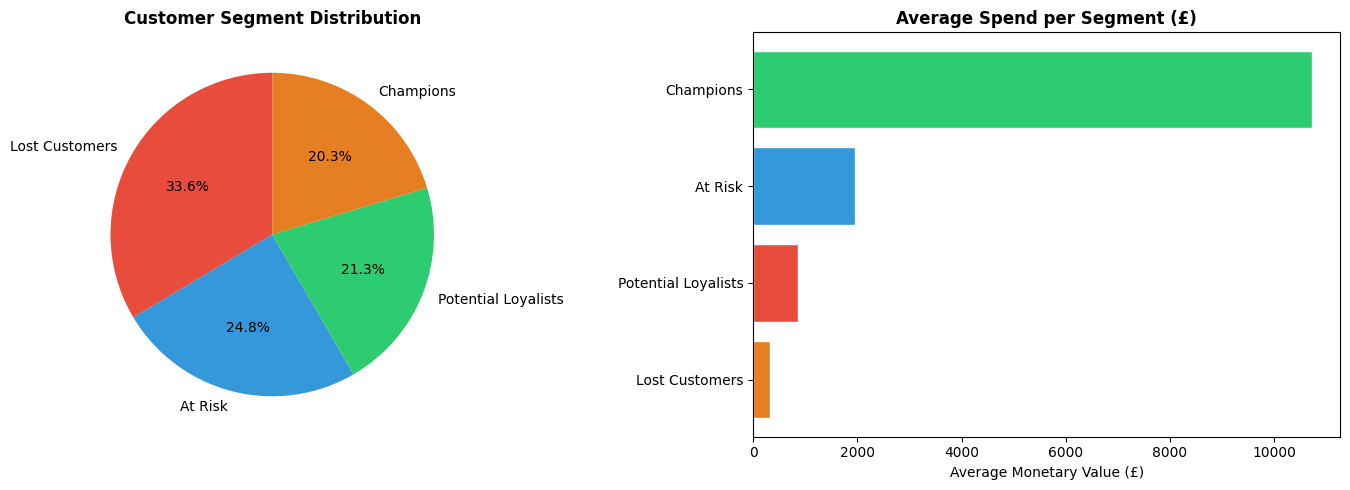

Segment Summary:
                     Recency  Frequency  Monetary
Segment                                          
At Risk               230.07       5.06   1948.50
Champions              27.71      19.28  10731.16
Lost Customers        394.95       1.38    317.08
Potential Loyalists    28.30       3.05    857.49

Segment Counts:
Segment
Lost Customers         1973
At Risk                1459
Potential Loyalists    1250
Champions              1196
Name: count, dtype: int64


In [6]:
# Assign segment names
segment_map = {
    0: 'Lost Customers',
    1: 'Potential Loyalists', 
    2: 'Champions',
    3: 'At Risk'
}
rfm['Segment'] = rfm['Cluster'].map(segment_map)

# Plot segment distribution
colors = ['#e74c3c','#3498db','#2ecc71','#e67e22']
seg_counts = rfm['Segment'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(seg_counts.values, labels=seg_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Customer Segment Distribution', fontweight='bold')

# Bar chart — avg monetary per segment
seg_monetary = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=True)
axes[1].barh(seg_monetary.index, seg_monetary.values,
             color=['#e67e22','#e74c3c','#3498db','#2ecc71'], edgecolor='white')
axes[1].set_title('Average Spend per Segment (£)', fontweight='bold')
axes[1].set_xlabel('Average Monetary Value (£)')

plt.tight_layout()
plt.savefig('../reports/plots/segmentation_results.png', dpi=150)
plt.show()

print("Segment Summary:")
print(rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(2))
print()
print("Segment Counts:")
print(seg_counts)

In [7]:
# Save results
rfm.to_csv("../data/features/rfm_segments.csv", index=False)

print("Segmentation saved!")
print()
print("Final file: data/features/rfm_segments.csv")
print()
print("="*45)
print("   SEGMENTATION COMPLETE")
print("="*45)
print(f"  Total customers:      {len(rfm):,}")
print(f"  Champions:            {len(rfm[rfm['Segment']=='Champions']):,} ({len(rfm[rfm['Segment']=='Champions'])/len(rfm)*100:.1f}%)")
print(f"  Potential Loyalists:  {len(rfm[rfm['Segment']=='Potential Loyalists']):,} ({len(rfm[rfm['Segment']=='Potential Loyalists'])/len(rfm)*100:.1f}%)")
print(f"  At Risk:              {len(rfm[rfm['Segment']=='At Risk']):,} ({len(rfm[rfm['Segment']=='At Risk'])/len(rfm)*100:.1f}%)")
print(f"  Lost Customers:       {len(rfm[rfm['Segment']=='Lost Customers']):,} ({len(rfm[rfm['Segment']=='Lost Customers'])/len(rfm)*100:.1f}%)")
print()
print("  Avg spend — Champions:      £10,731")
print("  Avg spend — At Risk:         £1,948")
print("  Avg spend — Pot. Loyalists:    £857")
print("  Avg spend — Lost Customers:    £317")
print("="*45)

Segmentation saved!

Final file: data/features/rfm_segments.csv

   SEGMENTATION COMPLETE
  Total customers:      5,878
  Champions:            1,196 (20.3%)
  Potential Loyalists:  1,250 (21.3%)
  At Risk:              1,459 (24.8%)
  Lost Customers:       1,973 (33.6%)

  Avg spend — Champions:      £10,731
  Avg spend — At Risk:         £1,948
  Avg spend — Pot. Loyalists:    £857
  Avg spend — Lost Customers:    £317
